<a href="https://colab.research.google.com/github/Rybus07/in-a-pickle/blob/main/notebooks/02_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction<a id='introduction'></a>

**Purpose:**

Explore univariate and bivariate distributions. \
    - For any given shot, what is the outcome of that shot, what is the opponent likely to hit, and what is the eventual outcome of the rally?

Explore visualization.

**Context:**

&emsp; Pickleball is an addictively fun racquet sport combining aspects of tennis, table tennis, and badminton and pickleball players are similarly diverse with players of all ages and all sports backgrounds. Players often spend hours on the courts both playing and socializing between games. A common topic of discussion amongst players is strategy with questions such as

* "Should I be dropping or driving my third shots?"
* "What kind of shots are more common at higher levels of play?"

This project aims to answer common questions in pickleball using data from pklmart.

**Data:**

Collection of pklmart data on Kaggle (https://www.kaggle.com/datasets/cakesofspan/pklmarts-competitive-pickleball-extracts). \
Pklmart (https://pklmart.com/)

**Outcomes from this notebook (EDA):**

1. Plotted univariate and bivariate distributions
    * Distributions showed trends in skill_lvl where players with skill_lvl of 4.5 and above played similarly and could be grouped into a larger class called 'Advanced'
    * Saw that cardinality of `shot_type` was high and needed to be reduced
2. Calculated adjacency matrices for my shot vs opponent's shot and my shot vs my next shot
    * While interesting, decided to go elsewhere with the project and pursue sequence prediction. Can come back to this later
3. Fit `rally_len` distributions to weibull distributions and log-normal
    * Lower skill levels are better fit with a weibull distribution
    * high skill levels had a longer tail and are better fit with a log-normal distribution
    * Fitted distributions are nice to have, but moving on with sequence prediction using RNNs

**Outcomes from previous notebook (data wrangling):**

1. Data were explored and cleaned where necessary. Remaining NaNs are largely inconsequential.
2. Merged shot.csv with rally.csv to create a master dataframe at the shot level. File is saved under shot_rally.csv and a script was created to recreate the file from the command line.


## To-Do:

1. Check rally_outcome, see if makes sense
    * corrected rally_outcome. saved over previous shot_rally.csv and corrected data wrangling notebook
    * shot_rally now contains complete rallies only (complete meaning rally_len matches the number of shots observed)
2. Merge shot_rally with itself to connect shot with next shot (likely will do a for loop since multiple rallies are contained in shot_rally)
    * Done. See get_ngram_shot_type function
3. Explore how immediate shot choice affects the game by exploring what was the outcome of the shot, what shots the opponents made, and what was the rally outcome
    * calculated adjacency matrix for current shot vs next shot (meaning opponents next shot) and current shot vs next 2-shot (next next shot, meaning my next shot)
    * need to combine this with shot outcome and rally outcome to see impact
4. Fit rally_len distribution to a probability distribution, possibly Poisson. If fits to a Poisson distribution, extract lambda value

## Contents<a id='contents'></a>
* [Introduction](#introduction)
* [Contents](#contents)
* [Objectives](#objectives)
* [Exploring Data](#exploring_data)
    * [Univariate Distributions](#univariate_distributions)
    * [Bivariate Distributions](#bivariate_distributions)
    * [Adjacency Matrices](#adjacency_matrices)
    * [Fitting](#fitting)

## Objectives <a id='objectives'></a>

1. Explore additional bivariates especially shot vs next shot
2. Explore how we can use data to develop a model
    * possible ideas are a shot recommender
    * game simulator playing more aggressive/defensive shots

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Andy's path to project data folder
data_path = '/content/drive/MyDrive/Colab Notebooks/DSCI 521 Final Project (Pickleball Analytics)/data/'

plt.rcParams.update({'font.size': 16})

In [ ]:
game_df = pd.read_csv(data_path+'raw/game.csv')
player_df = pd.read_csv(data_path+'raw/player.csv')
team_df = pd.read_csv(data_path+'raw/team.csv')
rally_df = pd.read_csv(data_path+'raw/rally.csv')
shot_df = pd.read_csv(data_path+'raw/shot.csv')

shot_type_ref = pd.read_csv(data_path+'raw/shot_type_ref.csv', index_col=0)

shot_rally_df = pd.read_csv(data_path+'shot_rally.csv', index_col=0)

## Exploring Data<a id='exploring_data'></a>

### Univariate Distributions<a id='univariate_distributions'></a>

**Detailed outcomes:**
1. Plotted univariate distributions from game, rally, and shot dataframes
    * Distribution of skill according to self-reported rating nearly linear excluding a peak for 4.0; 4.0 most represented at 35.1% of games; roughly 44.9% of games are 4.0 and below;
    * 60% of players do not have a reported DUPR rating so subsetting by skill will be done using self-reported game level
    * Rally length roughly follows a Poisson distribution
        * would be interesting to fit and to fit for different skill levels and then extract the lambda value
    * Rally ending type mostly errors
    * The most common shot is a dink following by hands battle/volley; third shot drops are more common that third shot drives
    * The most common shot outcome other than starting and extending rallies is an error
        * Underscores how pickleball really is a game of minimizing errors

In [ ]:
plt.rcParams.update({'font.size': 20})

#### Game Data<a id='game_data'></a>

Not much here

In [ ]:
game_df.head()

,game_id,match_id,game_nbr,score_w,score_l,w_team_id,l_team_id,skill_lvl,scoring_type,ball_type,dt_played
0,G347,M219,1,12,10,T311,T310,Pro,STANDARD_DOUBLES,D40,2022-10-25
1,G481,M317,1,5,5,T391,T390,4.0,STANDARD_DOUBLES,U,2023-10-01
2,G361,M227,1,15,9,T159,T321,3.5,STANDARD_DOUBLES,FX40,2023-10-21
3,G107,M54,1,11,4,T78,T82,4.5,STANDARD_DOUBLES,U,2023-02-25
4,G104,M52,1,11,5,T78,T79,4.5,STANDARD_DOUBLES,U,2023-02-25


Text(0, 0.5, 'Count')

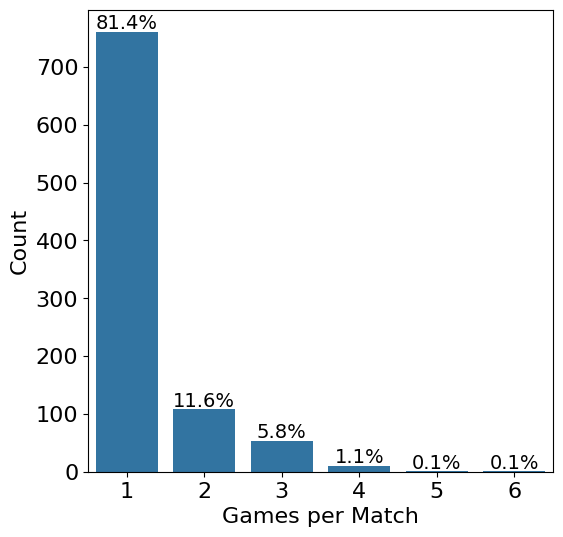

In [ ]:
# plotting count of games per match
fig = plt.figure(figsize=(6, 6))

total = game_df.shape[0]

ax = sns.countplot(data=game_df, x='game_nbr')

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2.,
            height + 5,
            '{:1.1f}%'.format(height/total*100),
            ha="center", size=14)

plt.xlabel('Games per Match')
plt.ylabel('Count')

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, '2.5'),
  Text(1, 0, '3.0'),
  Text(2, 0, '3.5'),
  Text(3, 0, '4.0'),
  Text(4, 0, '4.5'),
  Text(5, 0, '5.0'),
  Text(6, 0, '5.5'),
  Text(7, 0, 'Pro'),
  Text(8, 0, 'Senior Pro')])

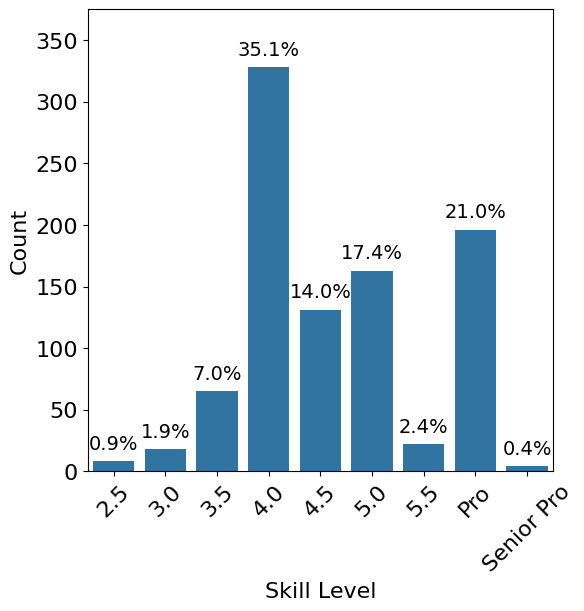

In [ ]:
# plotting count of skill level
fig = plt.figure(figsize=(6, 6))

total = game_df.shape[0]
skill_order = ['2.5', '3.0', '3.5', '4.0', '4.5', '5.0', '5.5',
               'Pro', 'Senior Pro']

ax = sns.countplot(data=game_df, x='skill_lvl', order=skill_order);

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2.,
        height + 10,
            '{:1.1f}%'.format(height/total*100),
        ha="center", size=14)

plt.ylim([0,375])
plt.ylabel('Count')
plt.xlabel('Skill Level')
plt.xticks(rotation=45)

#### Player Data<a id='player_data'></a>

Not much here

In [ ]:
player_df.head()

,player_id,gender,dom_hand,doubles_dupr,doublesreliabilityscore
0,P699,M,L,NaN,NaN
1,P600,M,R,4.101,5.0
2,P472,M,R,NaN,NaN
3,P320,M,R,NaN,0.0
4,P290,M,L,3.967,1.0


Text(47.120987654321, 0.5, 'Percent')

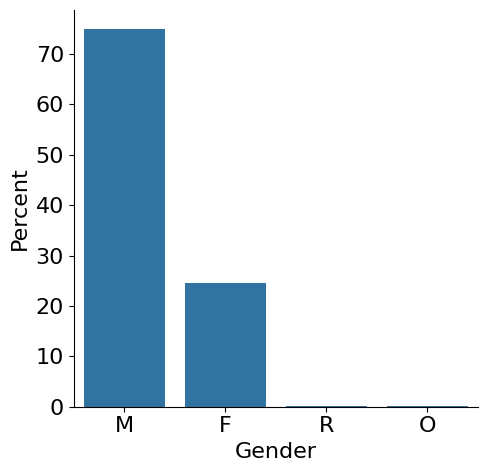

In [ ]:
sns.catplot(data=player_df, x='gender', kind='count', stat='percent')

plt.xlabel('Gender')
plt.ylabel('Percent')

Text(47.11654320987654, 0.5, 'Percent')

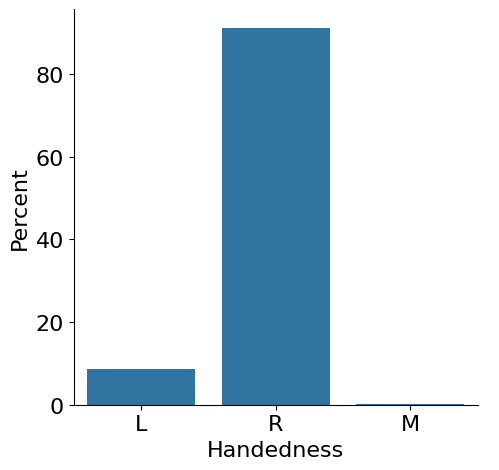

In [ ]:
sns.catplot(data=player_df, x='dom_hand', kind='count', stat='percent')

plt.xlabel('Handedness')
plt.ylabel('Percent')

Text(0, 0.5, 'Count')

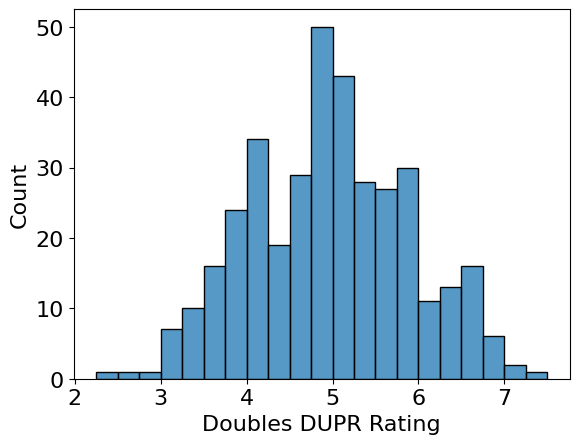

In [ ]:
sns.histplot(data=player_df, x='doubles_dupr', bins=np.arange(2.25, 7.75, 0.25))

plt.xlabel('Doubles DUPR Rating')
plt.ylabel('Count')

In [ ]:
shot_rally_df.head()

,match_id,game_id,rally_id,rally_nbr,rally_len,srv_team_id,rtrn_team_id,w_team_id,shot_id,shot_nbr,...,player_id,loc_x,loc_y,next_loc_x,next_loc_y,ending_type,shot_outcome,rally_outcome,next_shot_type,next_2-shot_type
289847,M99,G178,R7807,65,4,T135,T136,T135,S72059,4,...,P183,6.05,8.08,NaN,NaN,Unforced Error,Unforced Error,Game Over,NaN,NaN
289846,M99,G178,R7807,65,4,T135,T136,T135,S72058,3,...,P182,8.71,-20.58,6.05,8.08,Unforced Error,Winner,Game Over,HB,NaN
289845,M99,G178,R7807,65,4,T135,T136,T135,S72057,2,...,P184,17.53,20.76,8.71,-20.58,Unforced Error,Extend Rally,Game Over,tsDrv,HB
289844,M99,G178,R7807,65,4,T135,T136,T135,S72056,1,...,P181,7.42,-20.94,17.53,20.76,Unforced Error,Start Rally,Game Over,R,tsDrv
289843,M99,G178,R7806,64,4,T135,T136,T135,S72055,4,...,P184,11.56,7.72,NaN,NaN,Unforced Error,Unforced Error,Point,NaN,NaN


Text(48.636543209876564, 0.5, 'Count')

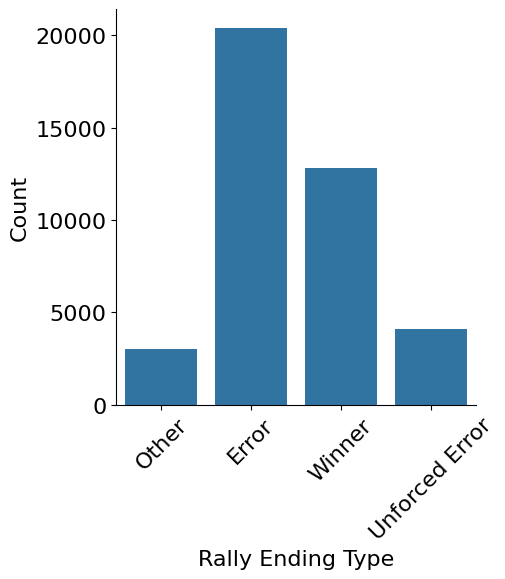

In [ ]:
sns.catplot(data=rally_df, x='ending_type', kind='count')

plt.xticks(rotation=45)
plt.xlabel('Rally Ending Type')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

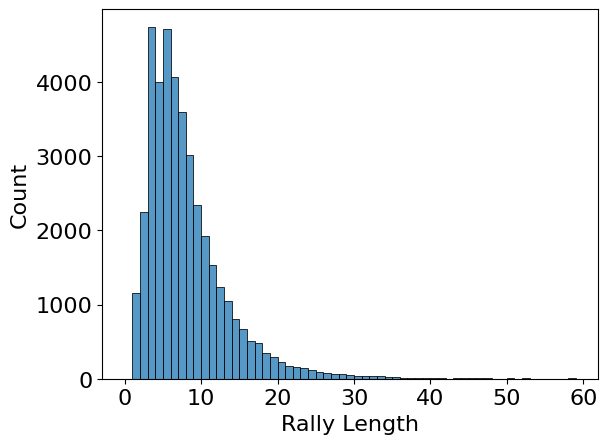

In [ ]:
sns.histplot(data=rally_df, x='rally_len', bins = np.arange(0,60,1))

plt.xlabel('Rally Length')
plt.ylabel('Count')

#### Shot and Rally Data<a id='shot_rally_data'></a>

Cardinality of `shot_type` is high and has a few rare classes that will need to be handled

In [ ]:
shot_df.columns

Index(['shot_id', 'rally_id', 'shot_nbr', 'shot_type', 'player_id', 'loc_x',
       'loc_y', 'next_loc_x', 'next_loc_y'],
      dtype='object')

Text(47.02561728395064, 0.5, 'Count')

<Figure size 2000x400 with 0 Axes>

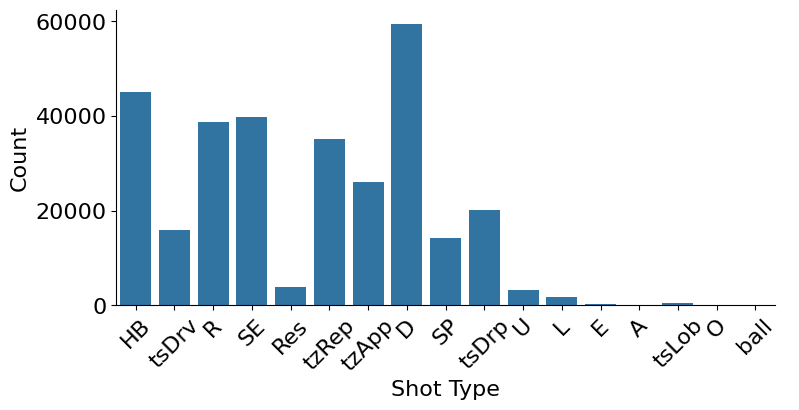

In [ ]:
fig = plt.figure(figsize=(20, 4))

sns.catplot(data=shot_rally_df, x='shot_type', kind='count', height=4, aspect=2)

plt.xticks(rotation=45)
plt.xlabel('Shot Type')
plt.ylabel('Count')

Text(0, 0.5, 'Percent')

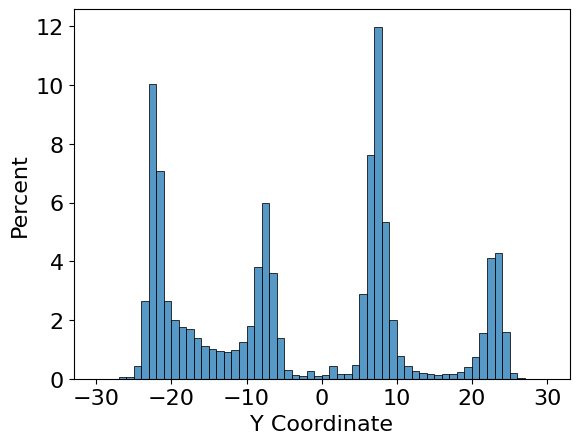

In [ ]:
sns.histplot(data=shot_rally_df, x='loc_y', bins=np.arange(-30, 31, 1), stat='percent')

plt.xlabel('Y Coordinate')
plt.ylabel('Percent')

Text(49.58790004748337, 0.5, 'Percent')

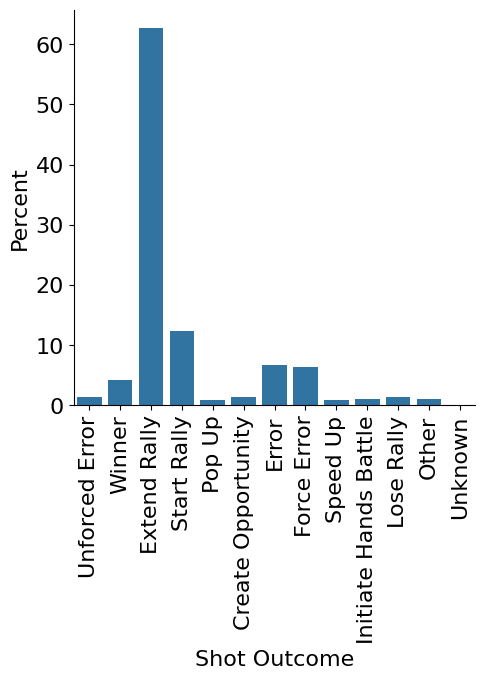

In [ ]:
sns.catplot(data=shot_rally_df, x='shot_outcome', kind='count', stat='percent')

plt.xticks(rotation=90)
plt.xlabel('Shot Outcome')
plt.ylabel('Percent')

Text(67.83139917695475, 0.5, 'Percent')

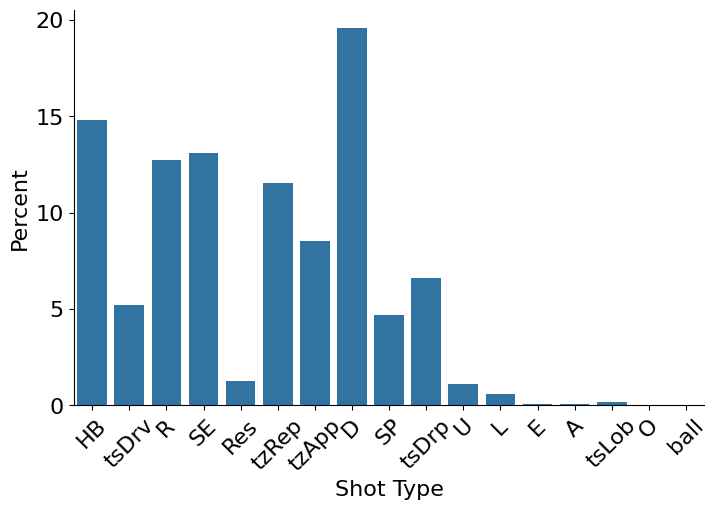

In [ ]:
sns.catplot(data=shot_rally_df, x='shot_type', kind='count', stat='percent', aspect=1.5)

plt.xticks(rotation=45)
plt.xlabel('Shot Type')
plt.ylabel('Percent')

### Bivariate Distributions<a id='bivariate_distributions'></a>

`skill_lvl` can be regrouped into `['Beginner', 'Intermediate', 'Advanced']` and most of data comes from `'Advanced'` players.

**Detailed Outcomes:**
1. Plotted bivariate distributions
    * Rally length increases with skill level
        * Fit these to a skewed distribution, possibly Poisson, and compare fitted values
    * At the beginner level, 2.5 DUPR, the most common rally ending type is an unforced error; Across all other levels, excluding senior pro, the most common rally ending type is an error, but it is possible that these are a mix of forced and unforced errors
        * Again underscores how important it is to minimize errors
    * At the 4.5 level and above, the most common shot is the dink with hands battles coming in second by a large gap; Below 4.5, the most common shot is hands battle; 3.0 and below third shot drives are more common than third shot drops while drops are favored for 3.5 and above; It appears that at 4.5 and above, players are getting to the net more frequently and dinking becomes more important

In [ ]:
game_df.head(3)

,game_id,match_id,game_nbr,score_w,score_l,w_team_id,l_team_id,skill_lvl,scoring_type,ball_type,dt_played
0,G347,M219,1,12,10,T311,T310,Pro,STANDARD_DOUBLES,D40,2022-10-25
1,G481,M317,1,5,5,T391,T390,4.0,STANDARD_DOUBLES,U,2023-10-01
2,G361,M227,1,15,9,T159,T321,3.5,STANDARD_DOUBLES,FX40,2023-10-21


In [ ]:
rally_df.head(3)

,rally_id,game_id,match_id,rally_nbr,w_team_id,srv_team_id,srv_player_id,rtrn_team_id,rtrn_player_id,ts_player_id,...,ending_type,ending_player_id,srv_switch_ind,rtrn_switch_ind,srv_team_flipped_ind,rtrn_team_flipped_ind,srv_team_rs_player_id,srv_team_ls_player_id,rtrn_team_rs_player_id,rtrn_team_ls_player_id
0,R8968,G208,M113,6,T152,T152,P202,T155,P70,P202,...,Other,NaN,Y,N,N,N,P203,P202,P70,P205
1,R8963,G208,M113,1,T155,T152,P202,T155,P70,NaN,...,Error,P203,Y,N,N,N,P203,P202,P70,P205
2,R8964,G208,M113,2,T152,T155,P70,T152,P202,P205,...,Error,P205,N,Y,N,N,P70,P205,P203,P202


Text(0, 0.5, 'Percent')

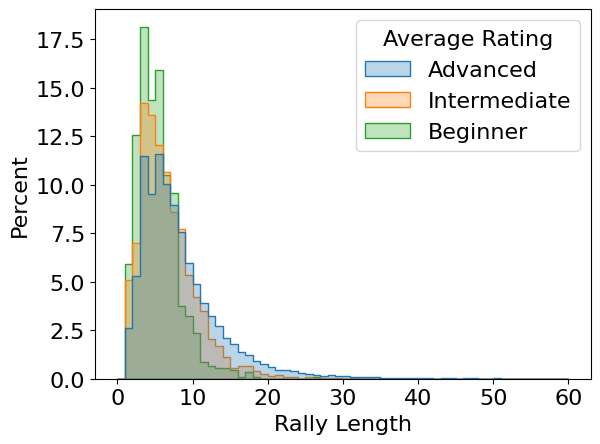

In [ ]:
# Rally length by dupr rating
skill_mapper = {'2.5':'Beginner', '3.0':'Beginner', '3.5':'Intermediate',
                '4.0':'Intermediate', '4.0':'Advanced', '4.5':'Advanced',
                '5.0':'Advanced', '5.5':'Advanced', 'Pro':'Advanced', 'Senior Pro':'Advanced'}
my_df = pd.merge(rally_df, game_df[['game_id', 'skill_lvl']], on='game_id',
                 how='left')
my_df['skill_lvl'] = my_df['skill_lvl'].map(skill_mapper)

ax = sns.histplot(data=my_df, x='rally_len', hue='skill_lvl', stat='percent',
             bins = np.arange(0, 61, 1), alpha=0.3, common_norm=False, element='step')

ax.get_legend().set_title('Average Rating')
plt.xlabel('Rally Length')
plt.ylabel('Percent')

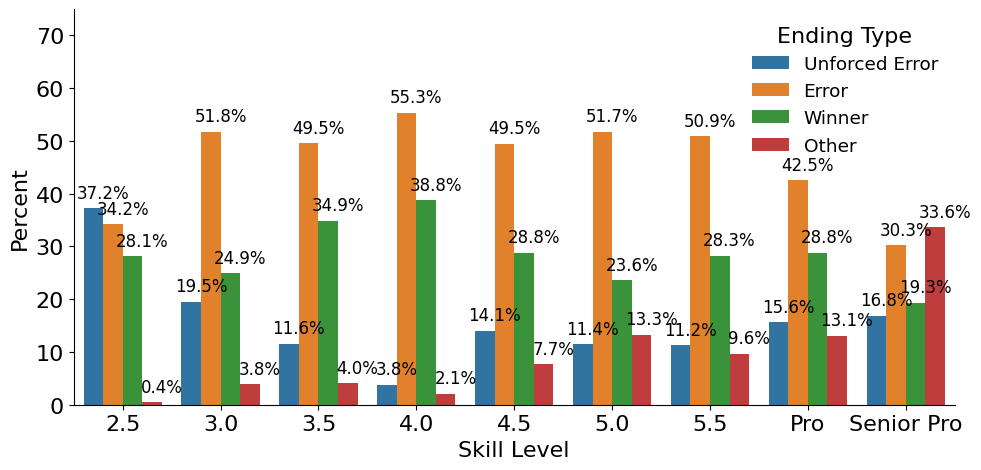

In [ ]:
# Rally ending type by rating
my_df = pd.merge(rally_df, game_df[['game_id', 'skill_lvl']], on='game_id',
                 how='left')[['skill_lvl', 'ending_type']]

x,y = 'skill_lvl', 'ending_type'

my_df = my_df.groupby(x)[y].value_counts(normalize=True)
my_df = my_df.mul(100)
my_df = my_df.rename('Percent').reset_index()

# mask  = [(x in ['2.5', '3.0', '3.5']) for x in my_df['skill_lvl']]
# my_df = my_df[mask]

g = sns.catplot(x=x,y='Percent',hue=y,kind='bar',data=my_df, aspect=2,
                legend='auto', legend_out=False)
g.ax.set_ylim(0,75)
g.ax.set_xlabel('Skill Level')
g.ax.legend(frameon=False, title='Ending Type', fontsize='small')

for i, p in enumerate(g.ax.patches):
    if i < 36:
        g.ax.text(p.get_x() + 0.2,
                p.get_height() + 2,
                f'{p.get_height():.1f}%',
                ha='center', size=12)

In [ ]:
shot_rally_df.head(3)

,match_id,game_id,rally_id,rally_nbr,rally_len,srv_team_id,rtrn_team_id,w_team_id,shot_id,shot_nbr,...,player_id,loc_x,loc_y,next_loc_x,next_loc_y,ending_type,shot_outcome,rally_outcome,next_shot_type,next_2-shot_type
289847,M99,G178,R7807,65,4,T135,T136,T135,S72059,4,...,P183,6.05,8.08,NaN,NaN,Unforced Error,Unforced Error,Game Over,NaN,NaN
289846,M99,G178,R7807,65,4,T135,T136,T135,S72058,3,...,P182,8.71,-20.58,6.05,8.08,Unforced Error,Winner,Game Over,HB,NaN
289845,M99,G178,R7807,65,4,T135,T136,T135,S72057,2,...,P184,17.53,20.76,8.71,-20.58,Unforced Error,Extend Rally,Game Over,tsDrv,HB


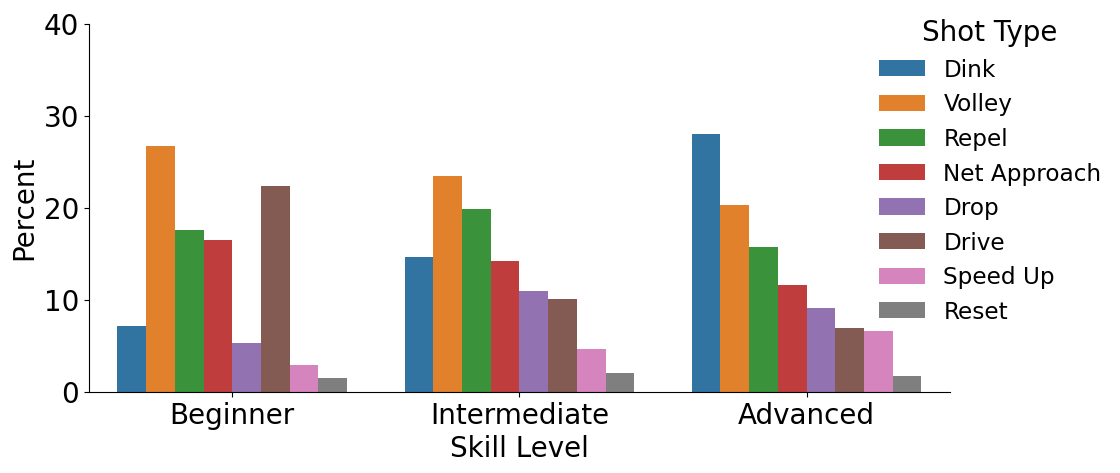

In [ ]:
# shot type vs game skill level, exclusing SE and R
shot_mapper = {'D':'Dink', 'HB':'Volley', 'SE':'Serve', 'R':'Return',
          'tzRep':'Repel', 'tzApp':'Net Approach', 'tsDrp':'Drop', 'tsDrv':'Drive',
          'SP':'Speed Up', 'Res':'Reset', 'U':'U', 'L':'Lob', 'tsLob':'Lob',
          'E':'Volley', 'A':'Speed Up', 'O':'O', 'ball':'ball'}
skill_mapper = {'2.5':'Beginner', '3.0':'Beginner', '3.5':'Intermediate',
                '4.0':'Intermediate', '4.0':'Advanced', '4.5':'Advanced',
                '5.0':'Advanced', '5.5':'Advanced', 'Pro':'Advanced', 'Senior Pro':'Advanced'}

shot_filter = ['HB', 'tsDrv', 'tsDrp', 'tzApp', 'tzRep', 'D', 'SP', 'Res']
mask = [(x in shot_filter) for x in shot_rally_df.shot_type]
my_df = shot_rally_df[['game_id', 'shot_type']][mask]
my_df = pd.merge(my_df,
                 game_df[['game_id', 'skill_lvl']], on='game_id',
                 how='left')[['skill_lvl', 'shot_type']]
my_df['shot_type'] = my_df['shot_type'].map(shot_mapper)
my_df['skill_lvl'] = my_df['skill_lvl'].map(skill_mapper)

x,y = 'skill_lvl', 'shot_type'

my_df = my_df.groupby(x)[y].value_counts(normalize=True)
my_df = my_df.mul(100)
my_df = my_df.rename('Percent').reset_index()

g = sns.catplot(x=x,y='Percent',hue=y,kind='bar',data=my_df, aspect=2,
                legend='auto', legend_out=False, order=['Beginner', 'Intermediate', 'Advanced'])
g.ax.set_ylim(0,40)
g.ax.set_xlabel('Skill Level')
g.ax.legend(frameon=False, title='Shot Type', fontsize='small',
            loc='right', bbox_to_anchor=(1.2, 0.6))

# for i, p in enumerate(g.ax.patches):
#     g.ax.text(p.get_x() + 0.2,
#             p.get_height() + 2,
#             f'{p.get_height():.1f}%',
#             ha='center', size=12)

Text(47.02561728395064, 0.5, 'Count')

<Figure size 2000x400 with 0 Axes>

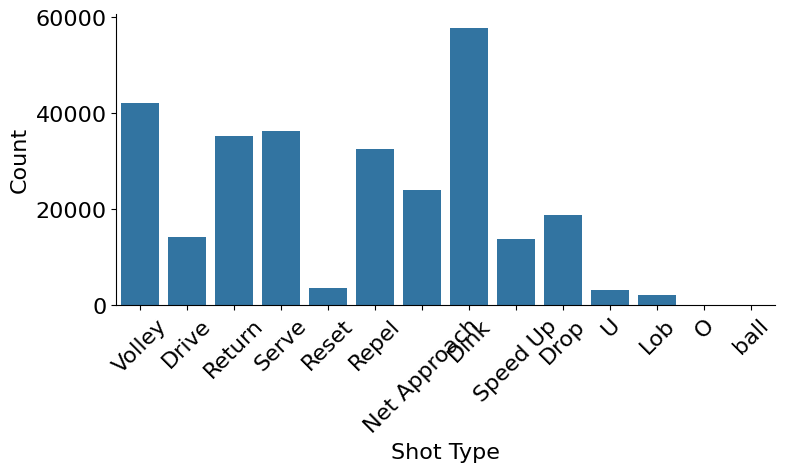

In [ ]:
shot_mapper = {'D':'Dink', 'HB':'Volley', 'SE':'Serve', 'R':'Return',
          'tzRep':'Repel', 'tzApp':'Net Approach', 'tsDrp':'Drop', 'tsDrv':'Drive',
          'SP':'Speed Up', 'Res':'Reset', 'U':'U', 'L':'Lob', 'tsLob':'Lob',
          'E':'Volley', 'A':'Speed Up', 'O':'O', 'ball':'ball'}
skill_mapper = {'2.5':'Beginner', '3.0':'Beginner', '3.5':'Intermediate',
                '4.0':'Intermediate', '4.0':'Advanced', '4.5':'Advanced',
                '5.0':'Advanced', '5.5':'Advanced', 'Pro':'Advanced', 'Senior Pro':'Advanced'}

my_df = shot_rally_df[['game_id', 'shot_type']]
my_df = pd.merge(my_df,
                 game_df[['game_id', 'skill_lvl']], on='game_id',
                 how='left')[['skill_lvl', 'shot_type']]
my_df['shot_type'] = my_df['shot_type'].map(shot_mapper)
my_df['skill_lvl'] = my_df['skill_lvl'].map(skill_mapper)

my_df = my_df[my_df['skill_lvl'] == 'Advanced']

fig = plt.figure(figsize=(20, 4))

sns.catplot(data=my_df, x='shot_type', kind='count', height=4, aspect=2)

plt.xticks(rotation=45)
plt.xlabel('Shot Type')
plt.ylabel('Count')

In [ ]:
from collections import Counter

In [ ]:
Counter(my_df['shot_type'])

Counter({'Volley': 42130,
         'Drive': 14209,
         'Return': 35355,
         'Serve': 36305,
         'Reset': 3554,
         'Repel': 32485,
         'Net Approach': 24039,
         'Dink': 57769,
         'Speed Up': 13784,
         'Drop': 18747,
         'U': 3163,
         'Lob': 2040,
         'O': 1,
         'ball': 6})

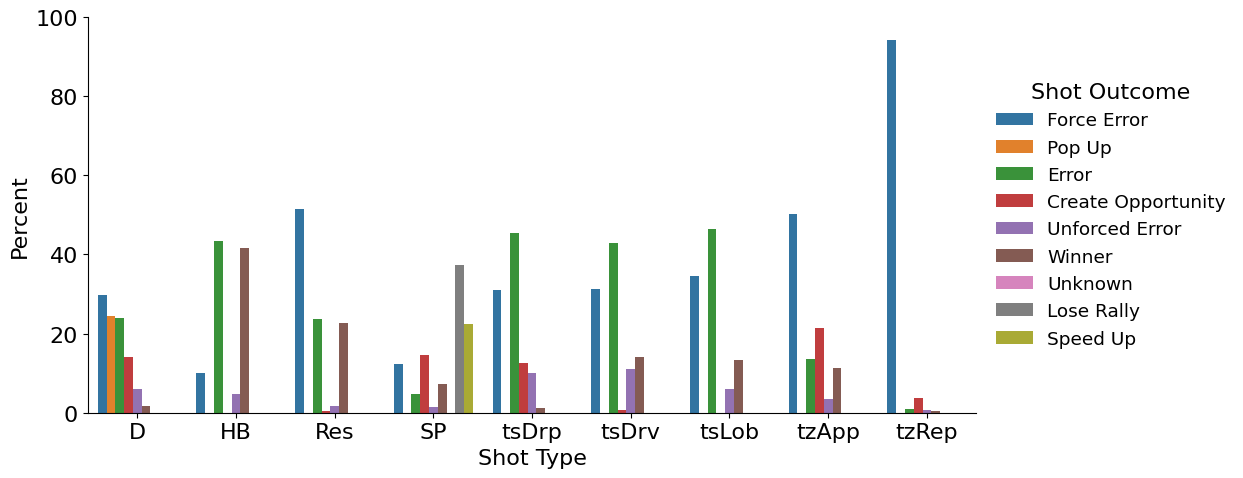

In [ ]:
# shot outcome vs shot type
shot_filter = ['SE', 'R', 'O', 'U', 'E', 'A', 'L', 'ball']
mask = [(x not in shot_filter) for x in shot_rally_df.shot_type]
my_df = shot_rally_df[['shot_type', 'shot_outcome']][mask]
outcome_filter = ['Extend Rally', 'Start Rally', 'Initiate Hands Battle',
                  'Other']
mask = [(x not in outcome_filter) for x in my_df.shot_outcome]
my_df = my_df[mask]

x,y = 'shot_type', 'shot_outcome'

my_df = my_df.groupby(x)[y].value_counts(normalize=True)
my_df = my_df.mul(100)
my_df = my_df.rename('Percent').reset_index()

g = sns.catplot(x=x,y='Percent',hue=y,kind='bar',data=my_df, aspect=2,
                legend='auto', legend_out=False)
g.ax.set_ylim(0,100)
g.ax.set_xlabel('Shot Type')
g.ax.legend(frameon=False, title='Shot Outcome', fontsize='small',
            loc='right', bbox_to_anchor=(1.3, 0.5))

# for i, p in enumerate(g.ax.patches):
#     g.ax.text(p.get_x() + 0.2,
#             p.get_height() + 2,
#             f'{p.get_height():.1f}%',
#             ha='center', size=12)

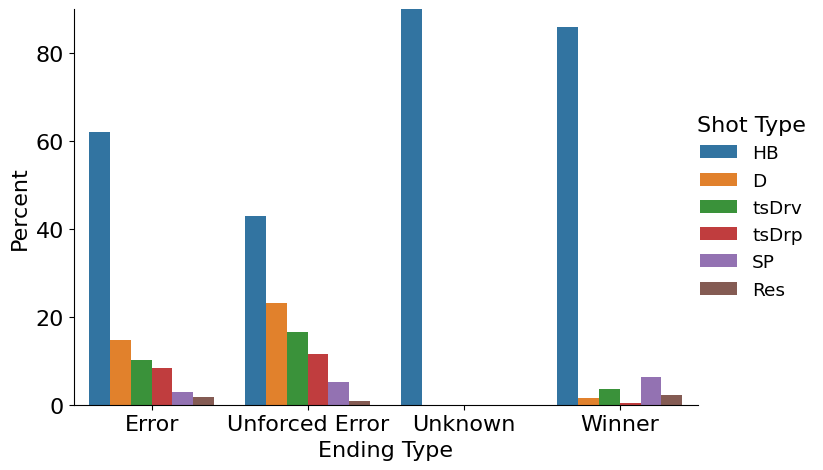

In [ ]:
# rally outcome by shot type
inds = []
cur_rally_id = ''
for i in shot_rally_df.index:
    if shot_rally_df.loc[i, 'rally_id'] != cur_rally_id:
        inds.append(i)
        cur_rally_id = shot_rally_df.loc[i, 'rally_id']

my_df = shot_rally_df.loc[inds][['ending_type', 'shot_type']]

shot_filter = ['SE', 'R', 'O', 'U', 'E', 'A', 'L', 'ball',
               'tzApp', 'tzLob', 'tzRep', 'tsLob']
mask = [(x not in shot_filter) for x in my_df.shot_type]
my_df = my_df[mask]
ending_filter = ['Other']
mask = [(x not in ending_filter) for x in my_df.ending_type]
my_df = my_df[mask]

x,y = 'ending_type', 'shot_type'

my_df = my_df.groupby(x)[y].value_counts(normalize=True)
my_df = my_df.mul(100)
my_df = my_df.rename('Percent').reset_index()

g = sns.catplot(x=x,y='Percent',hue=y,kind='bar',data=my_df, aspect=1.5,
                legend='auto', legend_out=False)
g.ax.set_ylim(0,90)
g.ax.set_xlabel('Ending Type')
g.ax.legend(frameon=False, title='Shot Type', fontsize='small',
            loc='right', bbox_to_anchor=(1.2, 0.5))

# for i, p in enumerate(g.ax.patches):
#     if i < 36:
#         g.ax.text(p.get_x() + 0.2,
#                 p.get_height() + 2,
#                 f'{p.get_height():.1f}%',
#                 ha='center', size=12)

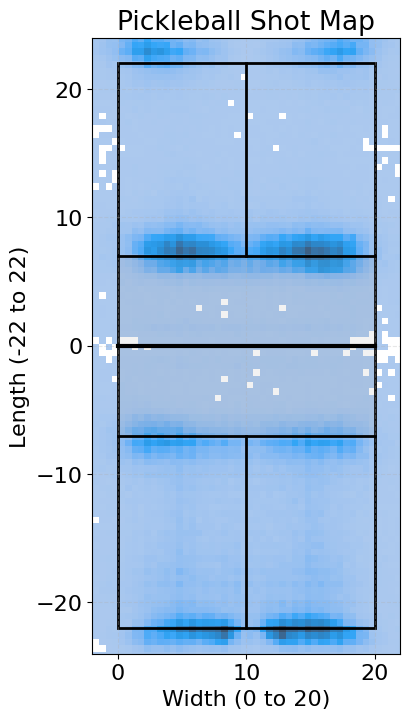

In [ ]:
fig, ax = plt.subplots(figsize=(6, 8))

# Dimensions based on your request
width = 20
half_length = 22
kitchen_offset = 7 # Standard kitchen is 7ft from net

# Plotting shot data first
ax = sns.histplot(data=shot_rally_df, x='loc_x', y='loc_y', binwidth=0.5)

# 1. Draw the Main Court Boundary
# Rectangle( (x_start, y_start), width, height )
court = patches.Rectangle((0, -half_length), width, half_length * 2,
                            linewidth=2, edgecolor='black', facecolor='none')
ax.add_patch(court)

# 2. Draw the Net (Center line at y=0)
ax.plot([0, width], [0, 0], color='black', linewidth=3, label='Net')

# 3. Draw Non-Volley Zone (Kitchen) lines
ax.plot([0, width], [kitchen_offset, kitchen_offset], color='black', linewidth=2)
ax.plot([0, width], [-kitchen_offset, -kitchen_offset], color='black', linewidth=2)

# 4. Draw Center lines (splitting the service courts)
# From top kitchen line to top baseline
ax.plot([width/2, width/2], [kitchen_offset, half_length], color='black', linewidth=2)
# From bottom kitchen line to bottom baseline
ax.plot([width/2, width/2], [-kitchen_offset, -half_length], color='black', linewidth=2)

# 5. Optional: Highlight the Kitchen Area
kitchen_top = patches.Rectangle((0, 0), width, kitchen_offset, color='gray', alpha=0.1)
kitchen_bottom = patches.Rectangle((0, -kitchen_offset), width, kitchen_offset, color='gray', alpha=0.1)
ax.add_patch(kitchen_top)
ax.add_patch(kitchen_bottom)

# Formatting
ax.set_xlim(-2, width + 2)
ax.set_ylim(-half_length - 2, half_length + 2)
ax.set_aspect('equal') # Crucial to keep the court proportions correct
ax.set_title("Pickleball Shot Map")
ax.set_xlabel("Width (0 to 20)")
ax.set_ylabel("Length (-22 to 22)")
ax.legend().remove()

plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

### Adjacency Matrices<a id='adjacency_matrices'></a>

Exploring adjacency matrices with shot vs next shot and shot vs next next shot

In [ ]:
shot_rally_df = pd.read_csv(data_path+'shot_rally.csv', index_col=0)

In [ ]:
def get_ngram_shot_type(df: pd.DataFrame, n: int, col_name: str) -> pd.DataFrame:
    '''
    Calculates n-grams of shot types assuming df has a column titled 'shot_type
        and a column titled 'rally_id'
    Returns df with additional column, col_name, containing n-gram
    Inputs:
        df: dataframe containing 'shot_type'; pd.DataFrame
        n: integer for n-gram, for n=1 calculates next shot type; int
        col_name: name of column to hold n-grams; str
    Outpts:
        df: new dataframe contain n-grams; pd.DataFrame
    '''
    inds = df.index
    next_shot_type = []
    prev_rally_id = ''
    prev_shot_type = ''
    gram_counter = n

    # loop through each row in shot_rally_df using index
    for i, ind in enumerate(inds):
        cur_rally_id = df.loc[ind, 'rally_id']
        # if reach new rally,
        # set next_shot_type = nan and set prev_rally_id to cur_rally_id
        if cur_rally_id != prev_rally_id:
            next_shot_type.append(np.nan)
            prev_rally_id = cur_rally_id
            gram_counter = n-1
        # otherwise, continue to add nans until counter reaches 0
        elif gram_counter > 0:
            next_shot_type.append(np.nan)
            gram_counter -= 1
        # gram_counter reaches 0 and in previous rally,
        # then set next shot type to prev shot type
        else:
            next_shot_type.append(prev_shot_type)
        # update prev_shot_type
        if i >= n-1:
            prev_shot_type = shot_rally_df.loc[inds[i-(n-1)], 'shot_type']

    df[col_name] = next_shot_type

    return df

In [ ]:
shot_rally_df = get_ngram_shot_type(shot_rally_df, 1, 'next_shot_type')
shot_rally_df = get_ngram_shot_type(shot_rally_df, 2, 'next_2-shot_type')

In [ ]:
# now creating adjacency matrix
adjacency_groupby = shot_rally_df[['shot_type', 'next_shot_type', 'shot_nbr']].groupby(['shot_type', 'next_shot_type']).count()
adjacency_groupby = adjacency_groupby.rename(columns={'shot_nbr':'count'})

adjacency_matrix = adjacency_groupby.unstack()
adjacency_matrix.columns = adjacency_matrix.columns.droplevel(0)

# normalizing rows
row_sums = adjacency_matrix.sum(axis=1)
adjacency_matrix = adjacency_matrix.div(row_sums, axis=0)
adjacency_matrix = adjacency_matrix.fillna(0)

In [ ]:
# and creating adjacency matrix for 2-shot gram
adjacency_groupby = shot_rally_df[['shot_type', 'next_2-shot_type', 'shot_nbr']].groupby(['shot_type', 'next_2-shot_type']).count()
adjacency_groupby = adjacency_groupby.rename(columns={'shot_nbr':'count'})

adjacency_2shot_matrix = adjacency_groupby.unstack()
adjacency_2shot_matrix.columns = adjacency_2shot_matrix.columns.droplevel(0)

# normalizing rows
row_sums = adjacency_2shot_matrix.sum(axis=1)
adjacency_2shot_matrix = adjacency_2shot_matrix.div(row_sums, axis=0)
adjacency_2shot_matrix = adjacency_2shot_matrix.fillna(0)

In [ ]:
pd.set_option('display.float_format', '{:,.3f}'.format)
adjacency_matrix

next_shot_type,A,D,E,HB,L,O,R,Res,SP,U,ball,tsDrp,tsDrv,tsLob,tzApp,tzRep
shot_type,,,,,,,,,,,,,,,,
A,0.000,0.000,0.000,0.738,0.016,0.000,0.000,0.115,0.049,0.033,0.000,0.000,0.000,0.000,0.049,0.000
D,0.002,0.761,0.002,0.065,0.010,0.000,0.000,0.002,0.128,0.008,0.000,0.000,0.000,0.000,0.009,0.014
E,0.017,0.026,0.000,0.534,0.009,0.000,0.000,0.060,0.060,0.000,0.000,0.000,0.000,0.000,0.276,0.017
HB,0.001,0.004,0.001,0.541,0.011,0.000,0.000,0.036,0.059,0.025,0.000,0.000,0.000,0.000,0.164,0.160
L,0.000,0.008,0.000,0.264,0.033,0.000,0.000,0.053,0.036,0.005,0.000,0.000,0.000,0.000,0.356,0.244
O,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
R,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.549,0.434,0.016,0.000,0.000
Res,0.000,0.064,0.004,0.613,0.009,0.000,0.000,0.055,0.086,0.012,0.000,0.000,0.000,0.000,0.110,0.046
SE,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


In [ ]:
adjacency_2shot_matrix

next_2-shot_type,A,D,E,HB,L,O,Res,SP,U,ball,tsDrp,tsDrv,tsLob,tzApp,tzRep
shot_type,,,,,,,,,,,,,,,
A,0.000,0.027,0.000,0.324,0.000,0.000,0.027,0.378,0.000,0.000,0.000,0.000,0.000,0.162,0.081
D,0.002,0.655,0.001,0.164,0.009,0.000,0.004,0.115,0.011,0.000,0.000,0.000,0.000,0.022,0.016
E,0.000,0.022,0.000,0.418,0.011,0.000,0.055,0.176,0.011,0.000,0.000,0.000,0.000,0.066,0.242
HB,0.000,0.121,0.002,0.440,0.006,0.000,0.023,0.070,0.029,0.000,0.000,0.000,0.000,0.091,0.219
L,0.000,0.031,0.000,0.211,0.134,0.000,0.065,0.017,0.018,0.000,0.000,0.000,0.000,0.372,0.152
R,0.000,0.202,0.001,0.167,0.001,0.000,0.003,0.032,0.025,0.000,0.000,0.000,0.000,0.045,0.524
Res,0.001,0.210,0.001,0.274,0.009,0.000,0.129,0.100,0.013,0.000,0.000,0.000,0.000,0.128,0.134
SE,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.549,0.434,0.016,0.000,0.000
SP,0.000,0.103,0.001,0.468,0.002,0.000,0.022,0.095,0.030,0.000,0.000,0.000,0.000,0.046,0.233


### Fitting<a id='fitting'></a>

Text(0, 0.5, 'Percent')

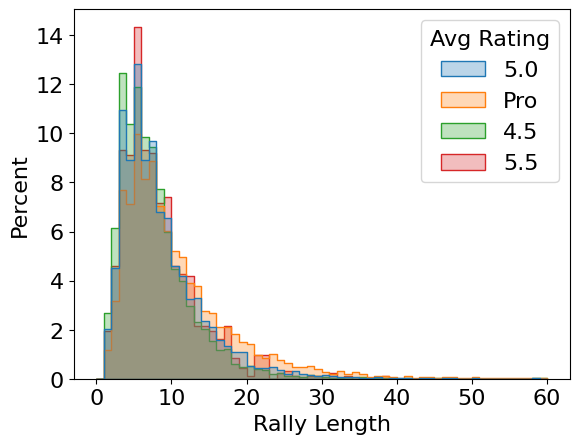

In [ ]:
# Rally length by dupr rating
my_df = pd.merge(rally_df, game_df[['game_id', 'skill_lvl']], on='game_id',
                 how='left')
mask = [(x in ['4.5', '5.0', '5.5', 'Pro']) for x in my_df['skill_lvl']]

ax = sns.histplot(data=my_df[mask], x='rally_len', hue='skill_lvl', stat='percent',
             bins = np.arange(0, 61, 1), alpha=0.3, common_norm=False,
             label='Avg Rating', element='step')

ax.get_legend().set_title('Avg Rating')
plt.xlabel('Rally Length')
plt.ylabel('Percent')

In [ ]:
from scipy.optimize import curve_fit
from scipy.special import factorial
from scipy.stats import poisson, lognorm, binom, geom

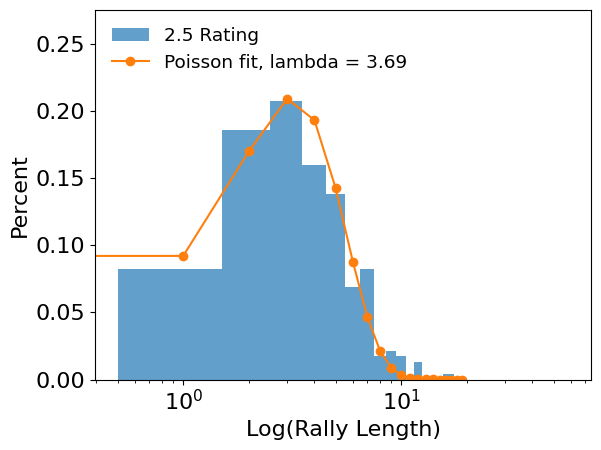

In [ ]:
data = my_df[my_df['skill_lvl']=='2.5']['rally_len']

# the bins should be of integer width, because poisson is an integer distribution
bins = np.arange(60) - 0.5
entries, bin_edges, patches = plt.hist(data, bins=bins, density=True,
                                       label='2.5 Rating', alpha=0.7)

# calculate bin centers
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])


def fit_function(k, lamb):
    '''poisson function, parameter lamb is the fit parameter'''
    return poisson.pmf(k, lamb)


# fit with curve_fit
parameters, cov_matrix = curve_fit(fit_function, bin_centers, entries)

# plot poisson-deviation with fitted parameter
x_plot = np.arange(0, 20)

plt.plot(
    x_plot,
    fit_function(x_plot, *parameters),
    marker='o', linestyle='-',
    label=f'Poisson fit, lambda = {parameters[0]:.2f}',
)
plt.xlabel('Log(Rally Length)')
plt.ylabel('Percent')
plt.xscale('log')
plt.ylim([0,0.275])
plt.legend(frameon=False, fontsize='small', loc=2)
plt.show()

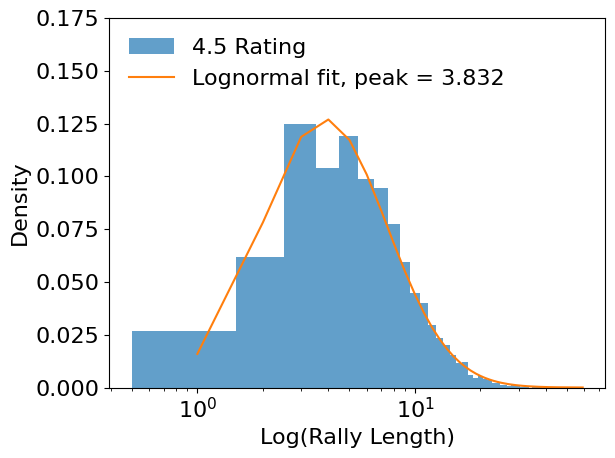

In [ ]:
my_df = pd.merge(rally_df, game_df[['game_id', 'skill_lvl']], on='game_id',
                 how='left')
my_df = my_df[my_df['rally_len'] > 0]
data = my_df[my_df['skill_lvl']=='4.5']['rally_len']

# 2. Fit the data to a lognormal distribution
# The 'fit' function returns the estimated shape, loc, and scale parameters.
# It is recommended to set floc=0 to fix the location parameter to zero.
shape_est, loc_est, scale_est = lognorm.fit(data, floc=0)

# 3. Interpret the estimated parameters
# The est mean (mu) of the *underlying* normal distribution can be derived:
mu_est = np.log(scale_est)
# The est standard deviation (sigma) of the *underlying* normal distribution
sigma_est = shape_est

# 4. Visualize the fit
data_sorted = np.sort(data)
pdf_fitted = lognorm.pdf(data_sorted, shape_est, loc_est, scale_est)

plt.hist(data, bins=np.arange(60) - 0.5, density=True, alpha=0.7,
         label='4.5 Rating')
plt.plot(data_sorted, pdf_fitted, marker='', linestyle='-',
         label=f'Lognormal fit, peak = {np.exp(mu_est-sigma_est**2):.3f}')
plt.xlabel('Log(Rally Length)')
plt.ylim([0,0.175])
plt.ylabel('Density')
plt.xscale('log')
plt.legend(frameon=False, loc=2)
plt.show()

In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def weibull(x, lam, k):
    '''Weibull distribution'''
    return (k/lam)*(x/lam)**(k-1)*np.exp(-(x/lam)**k)

def poisson(x, lam):
    return lam**x * (np.exp(-lam)) / factorial(x)

def plot_fit_rally_len(fit_function, skill_lvl):
    # create df of rally_len for given skill_lvl
    my_df = pd.merge(rally_df, game_df[['game_id', 'skill_lvl']], on='game_id',
                 how='left')
    my_df = my_df[my_df['rally_len'] > 0]
    data = my_df[my_df['skill_lvl']==skill_lvl][['rally_len', 'rally_id']]
    data_counts = data.groupby('rally_len').count()

    total_observations = data_counts.sum().values[0]
    # Convert counts to probabilities for fitting
    x = np.array(data_counts.index)
    y = data_counts['rally_id'].values/total_observations

    # plot histogram of rally_len
    bins = np.arange(60) - 0.5
    _, _, _ = plt.hist(data['rally_len'], bins=bins, density=True,
                                        label=skill_lvl+' Rating', alpha=0.7)

    # fit with curve_fit
    parameters, cov_matrix = curve_fit(fit_function, x, y)

    # plot weibull with fitted parameter
    yhat = fit_function(x, *parameters)

    print(rmse(y, yhat))
    print(*parameters)
    plt.plot(
        x,
        fit_function(x, *parameters),
        marker='o', linestyle='-',
        label='Function fit',
    )
    plt.xlabel('Log(Rally Length)')
    plt.ylabel('Percent')
    plt.xscale('log')
    plt.ylim([0,0.275])
    plt.legend(frameon=False, fontsize='small', loc=2)
    plt.show()

    return

In [ ]:
def fit_rally_len_weibull(skill_lvl):
    '''
    Fits distribution of rally_len for given skill_lvl to a Weibull distribution
    Returns x, y, yhat, parameters, error
    '''
    # create df of rally_len for given skill_lvl
    my_df = pd.merge(rally_df, game_df[['game_id', 'skill_lvl']], on='game_id',
                 how='left')
    my_df = my_df[my_df['rally_len'] > 0]
    data = my_df[my_df['skill_lvl']==skill_lvl][['rally_len', 'rally_id']]
    data_counts = data.groupby('rally_len').count()

    total_observations = data_counts.sum().values[0]
    # Convert counts to probabilities for fitting
    x = np.array(data_counts.index)
    y = data_counts['rally_id'].values/total_observations

    # fit with curve_fit
    parameters, cov_matrix = curve_fit(weibull, x, y)

    # plot weibull with fitted parameter
    yhat = weibull(x, *parameters)

    error = rmse(y, yhat)

    return x, y, yhat, parameters, error

def plot_rally_len_weibull(skill_lvls):
    fits = {}
    for x in skill_lvls:
        fits[x] = fit_rally_len_weibull(x)

    fig = plt.figure(figsize=(4, 4))

    for ind, val in enumerate(skill_lvls):
        x, y, yhat, parameters, error = fits[val]

        plt.plot(x, y, label=val+' Rating',
                 linewidth=1.5, color='C'+str(ind))
        plt.plot(
            x, yhat,
            linestyle='--', color='C'+str(ind),
            label=f'Fit (lambda, k) \n     ({parameters[0]:.2f}, {parameters[1]:.2f})',
        )

    plt.xlabel('Log(Rally Length)')
    plt.ylabel('Percent')
    plt.xscale('log')
    plt.ylim([0,0.15])
    plt.legend(frameon=False, fontsize='small',
               loc='right', bbox_to_anchor=(1.7, 0.5))
    return

/tmp/ipython-input-1858/2813995659.py:6: RuntimeWarning: invalid value encountered in power
  return (k/lam)*(x/lam)**(k-1)*np.exp(-(x/lam)**k)
/tmp/ipython-input-1858/2813995659.py:6: RuntimeWarning: invalid value encountered in power
  return (k/lam)*(x/lam)**(k-1)*np.exp(-(x/lam)**k)
/tmp/ipython-input-1858/2813995659.py:6: RuntimeWarning: invalid value encountered in power
  return (k/lam)*(x/lam)**(k-1)*np.exp(-(x/lam)**k)


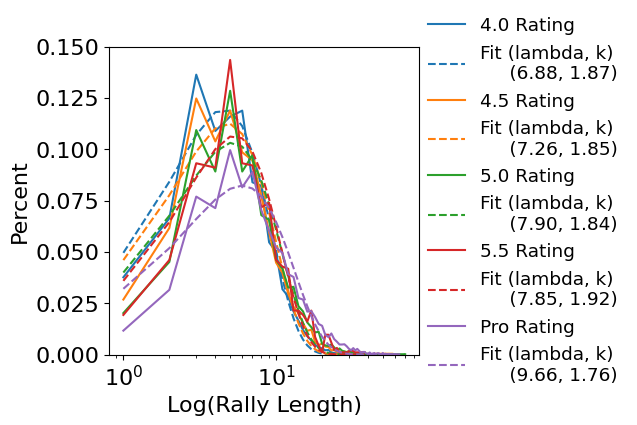

In [ ]:
plot_rally_len_weibull(['4.0', '4.5', '5.0', '5.5', 'Pro'])